# Work with realtime observations

Compare recent wind and water temperature at Buzzards Bay, Scripps, and Virginia Key. Learn to distinguish successful file downloads from available measurements.

The first code cell records when this notebook was executed against NOAA services.


In [1]:
from datetime import datetime, timezone
print("NOAA execution started (UTC):", datetime.now(timezone.utc).isoformat())

import matplotlib.pyplot as plt
import xndbc

station_ids = ["bzbm3", "46254", "vakf1"]

## Fetch the recent feed

Realtime retrieval takes station IDs without a year. NOAA determines the available time window, which changes as the feed updates.

Pass station datasets, ID strings, iterables, or scalar/one-dimensional ID DataArrays. Even one station retains its `station_id` dimension. Times are UTC, and station time axes align to their union with missing values where observations do not coincide. Retrieval performs no interpolation or averaging. The default product is `stdmet`; use `mode=` to choose another supported product.

In [2]:
data = xndbc.realtime(station_ids, progress=False)
data

<xarray.Dataset> Size: 5MB
Dimensions:       (station_id: 3, time: 13098)
Coordinates:
  * station_id    (station_id) object 24B 'bzbm3' '46254' 'vakf1'
    latitude      (station_id) float64 24B 41.52 32.87 25.73
    longitude     (station_id) float64 24B -70.67 -117.3 -80.16
    name          (station_id) <U76 912B '8447930 - Woods Hole, MA' ... '8723...
    owner         (station_id) <U3 36B 'O' 'R' 'O'
    station_type  (station_id) <U40 480B 'Water Level Observation Network' .....
    notes         (station_id) <U990 12kB 'Caution: Right whales may be activ...
  * time          (time) datetime64[us] 105kB 2026-07-27 ... 2026-09-10T14:00:00
Data variables: (12/14)
    WDIR          (station_id, time) float64 314kB nan nan nan ... 90.0 nan 90.0
    WSPD          (station_id, time) float64 314kB nan nan nan ... 3.6 nan 3.1
    GST           (station_id, time) float64 314kB nan nan nan ... 5.1 nan 4.1
    WVHT          (station_id, time) float64 314kB nan nan nan ... nan nan nan
    DPD           (station_id, time) float64 314kB nan nan nan ... nan nan nan
    APD           (station_id, time) float64 314kB nan nan nan ... nan nan nan
    ...            ...
    ATMP          (station_id, time) float64 314kB 19.0 nan nan ... nan 30.8
    WTMP          (station_id, time) float64 314kB 25.6 25.6 25.6 ... nan 30.8
    DEWP          (station_id, time) float64 314kB nan nan nan ... nan nan nan
    VIS           (station_id, time) float64 314kB nan nan nan ... nan nan nan
    PTDY          (station_id, time) float64 314kB 0.0 nan nan ... nan nan 1.3
    TIDE          (station_id, time) float64 314kB nan nan nan ... nan nan nan
Attributes:
    source:        NOAA National Data Buoy Center
    feed:          realtime
    ndbc_mode:     stdmet
    retrieved_at:  2026-09-10T14:52:29.328274+00:00
    ndbc_report:   [{"station_id": "bzbm3", "year": null, "url": "https://www...
    sampling:      Original observations; no temporal resampling

In [3]:
data.time.isel(time=[0, -1])

<xarray.DataArray 'time' (time: 2)> Size: 16B
array(['2026-07-27T00:00:00.000000', '2026-09-10T14:00:00.000000'],
      dtype='datetime64[us]')
Coordinates:
  * time     (time) datetime64[us] 16B 2026-07-27 2026-09-10T14:00:00
Attributes:
    standard_name:  time
    long_name:      Time
    timezone:       UTC

## Inspect file outcomes and measurements

The report tracks files. Coverage tracks measurements inside the successful downloads. A station can have a successful file and no wind-speed measurements. Missing values remain missing; they are never replaced with zero.

Partial failures return successful data and emit one warning. An all-failed request raises `xndbc.RetrievalError`. Use `errors="raise"` to require every file to succeed, and inspect the exception’s `report` for failure details. Reports describe the original request even after selecting a subset of observations.

In [4]:
data.ndbc.report()

<xarray.Dataset> Size: 804B
Dimensions:     (request: 3)
Coordinates:
  * request     (request) int64 24B 0 1 2
Data variables:
    station_id  (request) <U5 60B 'bzbm3' '46254' 'vakf1'
    url         (request) <U50 600B 'https://www.ndbc.noaa.gov/data/realtime2...
    status      (request) <U7 84B 'success' 'success' 'success'
    error       (request) <U1 12B '' '' ''
    year        (request) float64 24B nan nan nan
Attributes:
    description:  Original download request outcomes; year is missing for rea...

In [5]:
data[["WSPD", "WTMP"]].ndbc.coverage("h")

<xarray.Dataset> Size: 13kB
Dimensions:       (station_id: 3)
Coordinates:
  * station_id    (station_id) object 24B 'bzbm3' '46254' 'vakf1'
    latitude      (station_id) float64 24B 41.52 32.87 25.73
    longitude     (station_id) float64 24B -70.67 -117.3 -80.16
    name          (station_id) <U76 912B '8447930 - Woods Hole, MA' ... '8723...
    owner         (station_id) <U3 36B 'O' 'R' 'O'
    station_type  (station_id) <U40 480B 'Water Level Observation Network' .....
    notes         (station_id) <U990 12kB 'Caution: Right whales may be activ...
Data variables:
    WSPD          (station_id) float64 24B 0.0 0.0 100.0
    WTMP          (station_id) float64 24B 22.83 99.63 100.0
Attributes:
    frequency:     h
    window_start:  2026-07-27T00:00:00.000000000
    window_end:    2026-09-10T14:00:00.000000000
    time_bins:     1095
    definition:    Percent of bins containing at least one nonmissing observa...

## Compare wind speed

Remove stations with no wind observations before plotting. Hourly means make the small station comparison easier to read. Coverage above still includes stations that have no measurements.

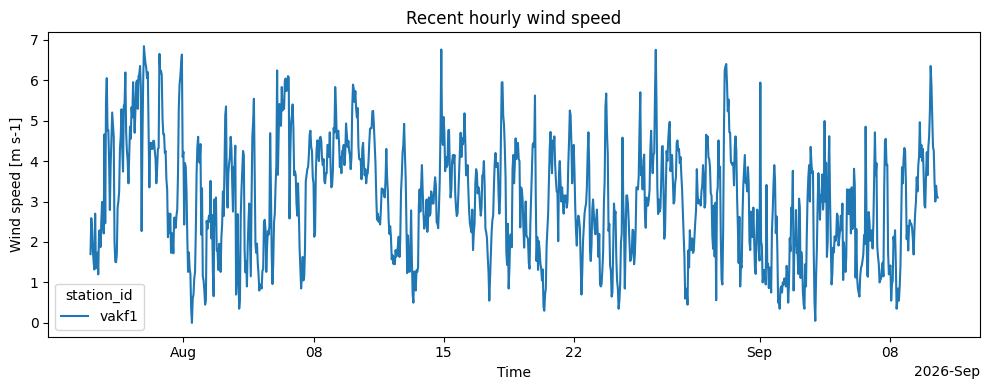

In [6]:
wind = data.WSPD.dropna("station_id", how="all")
hourly_wind = wind.resample(time="h").mean(keep_attrs=True)
hourly_wind.plot.line(x="time", hue="station_id", figsize=(10, 4))
plt.title("Recent hourly wind speed")
plt.tight_layout()
plt.show()

## Compare water temperature

Repeat the same explicit operation for a different measurement. The stations contributing to this plot can differ from those in the wind plot.

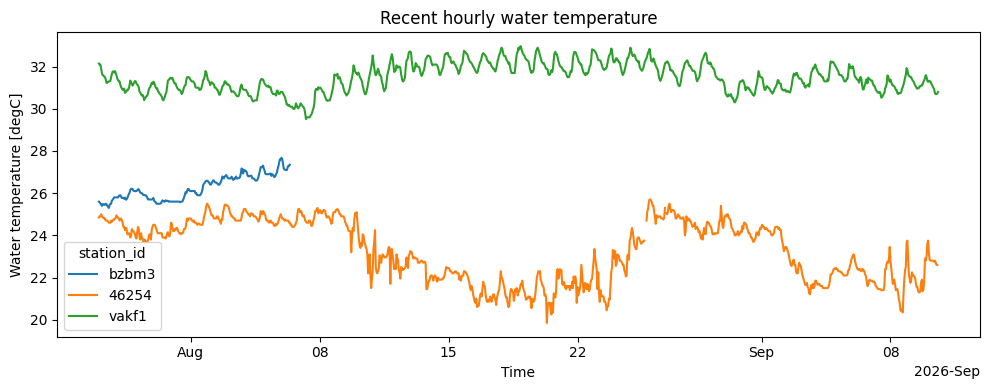

In [7]:
temperature = data.WTMP.dropna("station_id", how="all")
hourly_temperature = temperature.resample(time="h").mean(keep_attrs=True)
hourly_temperature.plot.line(x="time", hue="station_id", figsize=(10, 4))
plt.title("Recent hourly water temperature")
plt.tight_layout()
plt.show()

If you change the station selection, inspect its variables and coverage first. Not every station measures wind or water temperature. See [Historical Analysis](historical_analysis.ipynb) for coverage over an explicit calendar window.